# Mini Project 6 - Analisis Traffic Crashes

Notebook ini menggabungkan tiga file CSV:

- `traffic_crashes.csv`: data utama kecelakaan.
- `traffic_crash_vehicle.csv`: data kendaraan per kecelakaan.
- `traffic_crash_people.csv`: data orang/pengemudi/penumpang per kecelakaan.

Strategi penggabungan: data kendaraan dan orang adalah relasi one-to-many terhadap `crash_record_id`, jadi keduanya diagregasi terlebih dahulu per kecelakaan. Setelah itu hasil agregasi digabungkan ke tabel utama agar satu baris tetap merepresentasikan satu kejadian kecelakaan.

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', 120)
sns.set_theme(style='whitegrid')

DATA_DIR = Path('.')
DB_PATH = DATA_DIR / 'traffic_crash_analysis.sqlite'

## 1. Load Data

In [2]:
crashes = pd.read_csv(DATA_DIR / 'traffic_crashes.csv')
vehicles = pd.read_csv(DATA_DIR / 'traffic_crash_vehicle.csv')
people = pd.read_csv(DATA_DIR / 'traffic_crash_people.csv')

print('traffic_crashes:', crashes.shape)
print('traffic_crash_vehicle:', vehicles.shape)
print('traffic_crash_people:', people.shape)

traffic_crashes: (1000, 49)
traffic_crash_vehicle: (1000, 72)
traffic_crash_people: (1000, 30)


In [3]:
crashes.head()

,crash_record_id,rd_no,crash_date_est_i,crash_date,posted_speed_limit,traffic_control_device,device_condition,weather_condition,lighting_condition,first_crash_type,trafficway_type,lane_cnt,alignment,roadway_surface_cond,road_defect,report_type,crash_type,intersection_related_i,private_property_i,hit_and_run_i,damage,date_police_notified,prim_contributory_cause,sec_contributory_cause,street_no,street_direction,street_name,beat_of_occurrence,photos_taken_i,statements_taken_i,dooring_i,work_zone_i,work_zone_type,workers_present_i,num_units,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,injuries_unknown,crash_hour,crash_day_of_week,crash_month,latitude,longitude,location
0,530411c8611eb0ccb9b25f16b2955cd21761fa1928dcaa...,JE494048,NaN,2021-12-31T14:00:00.000,35,NO CONTROLS,NO CONTROLS,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,NaN,STRAIGHT AND LEVEL,DRY,NO DEFECTS,ON SCENE,INJURY AND / OR TOW DUE TO CRASH,NaN,NaN,NaN,"OVER $1,500",2021-12-31T14:00:00.000,UNABLE TO DETERMINE,NOT APPLICABLE,6021,S,ARCHER AVE,811,NaN,NaN,NaN,NaN,NaN,NaN,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0.0,14,6,12,41.794850,-87.767280,POINT (-87.767280356289 41.794849958048)
1,305b06235b250aa0029c07313c84f969f4bc13c1cc3715...,JE494008,NaN,2021-12-31T14:00:00.000,30,TRAFFIC SIGNAL,UNKNOWN,CLEAR,DUSK,TURNING,FOUR WAY,NaN,STRAIGHT AND LEVEL,DRY,NO DEFECTS,ON SCENE,INJURY AND / OR TOW DUE TO CRASH,Y,NaN,Y,"OVER $1,500",2021-12-31T14:15:00.000,FAILING TO YIELD RIGHT-OF-WAY,DISREGARDING YIELD SIGN,2400,W,MADISON ST,1222,NaN,Y,NaN,NaN,NaN,NaN,3,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0.0,14,6,12,41.881271,-87.686536,POINT (-87.686535940171 41.881270504288)
2,444221c2a9bc82fc4f301062ab22b482d7d661cf88fcdf...,JE494016,Y,2021-12-31T13:56:00.000,10,OTHER,NO CONTROLS,CLEAR,DAYLIGHT,SIDESWIPE SAME DIRECTION,PARKING LOT,NaN,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NOT ON SCENE (DESK REPORT),NO INJURY / DRIVE AWAY,NaN,Y,NaN,"$501 - $1,500",2021-12-31T14:20:00.000,UNABLE TO DETERMINE,UNABLE TO DETERMINE,9400,S,ASHLAND AVE,2221,NaN,NaN,NaN,NaN,NaN,NaN,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0.0,13,6,12,41.722941,-87.662863,POINT (-87.662862871273 41.72294121821)
3,4603435fbb4ef5d45c0d805c3e9aa5558a311a140a737e...,JE494049,NaN,2021-12-31T13:46:00.000,30,NO CONTROLS,NO CONTROLS,RAIN,DAYLIGHT,PEDALCYCLIST,DIVIDED - W/MEDIAN BARRIER,NaN,STRAIGHT AND LEVEL,WET,NO DEFECTS,NOT ON SCENE (DESK REPORT),INJURY AND / OR TOW DUE TO CRASH,NaN,NaN,NaN,$500 OR LESS,2021-12-31T15:13:00.000,UNABLE TO DETERMINE,UNABLE TO DETERMINE,1910,E,71ST ST,332,NaN,NaN,NaN,NaN,NaN,NaN,2,NONINCAPACITATING INJURY,1.0,0.0,0.0,1.0,0.0,2.0,0.0,13,6,12,41.766336,-87.578270,POINT (-87.578269718478 41.766335621716)
4,db62bb4534d0dae57112ea3ff8d50193784aaa732ed58d...,JE494000,NaN,2021-12-31T13:45:00.000,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,CLEAR,DAYLIGHT,SIDESWIPE SAME DIRECTION,NOT DIVIDED,NaN,STRAIGHT AND LEVEL,WET,NO DEFECTS,ON SCENE,NO INJURY / DRIVE AWAY,NaN,NaN,Y,"OVER $1,500",2021-12-31T15:50:00.000,IMPROPER LANE USAGE,DRIVING SKILLS/KNOWLEDGE/EXPERIENCE,7900,S,LANGLEY AVE,624,NaN,NaN,NaN,NaN,NaN,NaN,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0.0,13,6,12,41.751150,-87.607802,POINT (-87.607802036151 41.7511501753)


In [4]:
vehicles.head()

,crash_unit_id,crash_record_id,rd_no,crash_date,unit_no,unit_type,num_passengers,vehicle_id,cmrc_veh_i,make,model,lic_plate_state,vehicle_year,vehicle_defect,vehicle_type,vehicle_use,travel_direction,maneuver,towed_i,fire_i,occupant_cnt,exceed_speed_limit_i,towed_by,towed_to,area_00_i,area_01_i,area_02_i,area_03_i,area_04_i,area_05_i,area_06_i,area_07_i,area_08_i,area_09_i,area_10_i,area_11_i,area_12_i,area_99_i,first_contact_point,cmv_id,usdot_no,ccmc_no,ilcc_no,commercial_src,gvwr,carrier_name,carrier_state,carrier_city,hazmat_placards_i,hazmat_name,un_no,hazmat_present_i,hazmat_report_i,hazmat_report_no,mcs_report_i,mcs_report_no,hazmat_vio_cause_crash_i,mcs_vio_cause_crash_i,idot_permit_no,wide_load_i,trailer1_width,trailer2_width,trailer1_length,trailer2_length,total_vehicle_length,axle_cnt,vehicle_config,cargo_body_type,load_type,hazmat_out_of_service_i,mcs_out_of_service_i,hazmat_class
0,1255349,305b06235b250aa0029c07313c84f969f4bc13c1cc3715...,JE494008,2021-12-31T14:00:00.000,1,DRIVER,NaN,1191605.0,NaN,DODGE,CHARGER,IL,NaN,UNKNOWN,UNKNOWN/NA,UNKNOWN/NA,W,TURNING LEFT,Y,NaN,1.0,NaN,NaN,NaN,NaN,Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,Y,NaN,OTHER,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1255350,305b06235b250aa0029c07313c84f969f4bc13c1cc3715...,JE494008,2021-12-31T14:00:00.000,2,DRIVER,NaN,1191608.0,NaN,KIA,SEDONA,IL,2021.0,UNKNOWN,UNKNOWN/NA,UNKNOWN/NA,N,STRAIGHT AHEAD,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1255351,305b06235b250aa0029c07313c84f969f4bc13c1cc3715...,JE494008,2021-12-31T14:00:00.000,3,PARKED,NaN,1191614.0,NaN,CHRYSLER,PACIFICA,IL,2006.0,NONE,VAN/MINI-VAN,PERSONAL,E,PARKED,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,OTHER,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1255367,530411c8611eb0ccb9b25f16b2955cd21761fa1928dcaa...,JE494048,2021-12-31T14:00:00.000,1,DRIVER,NaN,1191620.0,NaN,TOYOTA,TUNDRA,IL,2008.0,NONE,PICKUP,PERSONAL,N,U-TURN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,Y,Y,N,NaN,NaN,ROOF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1255368,530411c8611eb0ccb9b25f16b2955cd21761fa1928dcaa...,JE494048,2021-12-31T14:00:00.000,2,DRIVER,NaN,1191622.0,NaN,GENERAL MOTORS CORPORATION (GMC),ENVOY,IL,2003.0,NONE,SPORT UTILITY VEHICLE (SUV),PERSONAL,E,STRAIGHT AHEAD,Y,NaN,1.0,NaN,PRIVATE,NaN,NaN,Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Y,Y,NaN,OTHER,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
people.head()

,person_id,person_type,crash_record_id,rd_no,vehicle_id,crash_date,seat_no,city,state,zipcode,sex,age,drivers_license_state,drivers_license_class,safety_equipment,airbag_deployed,ejection,injury_classification,hospital,ems_agency,ems_run_no,driver_action,driver_vision,physical_condition,pedpedal_action,pedpedal_visibility,pedpedal_location,bac_result,bac_result_value,cell_phone_use
0,O1255349,DRIVER,305b06235b250aa0029c07313c84f969f4bc13c1cc3715...,JE494008,1191605.0,2021-12-31T14:00:00.000,NaN,NaN,NaN,NaN,M,NaN,XX,NaN,USAGE UNKNOWN,DEPLOYMENT UNKNOWN,UNKNOWN,NO INDICATION OF INJURY,NaN,NaN,NaN,FAILED TO YIELD,UNKNOWN,UNKNOWN,NaN,NaN,NaN,TEST NOT OFFERED,NaN,NaN
1,O1255350,DRIVER,305b06235b250aa0029c07313c84f969f4bc13c1cc3715...,JE494008,1191608.0,2021-12-31T14:00:00.000,NaN,NaN,NaN,NaN,X,NaN,NaN,NaN,NONE PRESENT,DEPLOYMENT UNKNOWN,UNKNOWN,NO INDICATION OF INJURY,NaN,NaN,NaN,UNKNOWN,UNKNOWN,UNKNOWN,NaN,NaN,NaN,TEST REFUSED,NaN,NaN
2,O1255367,DRIVER,530411c8611eb0ccb9b25f16b2955cd21761fa1928dcaa...,JE494048,1191620.0,2021-12-31T14:00:00.000,NaN,CHICAGO,IL,60638,M,62.0,IL,D,SAFETY BELT USED,NOT APPLICABLE,NONE,NO INDICATION OF INJURY,NaN,NaN,NaN,IMPROPER TURN,UNKNOWN,NORMAL,NaN,NaN,NaN,TEST NOT OFFERED,NaN,NaN
3,O1255368,DRIVER,530411c8611eb0ccb9b25f16b2955cd21761fa1928dcaa...,JE494048,1191622.0,2021-12-31T14:00:00.000,NaN,CHICAGO,IL,60638,F,64.0,IL,D,SAFETY BELT USED,NOT APPLICABLE,NONE,NO INDICATION OF INJURY,NaN,NaN,NaN,NONE,UNKNOWN,NORMAL,NaN,NaN,NaN,TEST NOT OFFERED,NaN,NaN
4,O1255343,DRIVER,444221c2a9bc82fc4f301062ab22b482d7d661cf88fcdf...,JE494016,1191596.0,2021-12-31T13:56:00.000,NaN,NaN,NaN,NaN,F,NaN,NaN,NaN,USAGE UNKNOWN,DEPLOYMENT UNKNOWN,NONE,NO INDICATION OF INJURY,NaN,NaN,NaN,UNKNOWN,UNKNOWN,UNKNOWN,NaN,NaN,NaN,TEST NOT OFFERED,NaN,NaN


## 2. Cleaning Ringan

In [6]:
for df in (crashes, vehicles, people):
    if 'crash_date' in df.columns:
        df['crash_date'] = pd.to_datetime(df['crash_date'], errors='coerce')

numeric_crash_cols = [
    'posted_speed_limit', 'lane_cnt', 'street_no', 'beat_of_occurrence', 'num_units',
    'injuries_total', 'injuries_fatal', 'injuries_incapacitating',
    'injuries_non_incapacitating', 'injuries_reported_not_evident',
    'injuries_no_indication', 'injuries_unknown', 'crash_hour', 'crash_day_of_week',
    'crash_month', 'latitude', 'longitude'
]
for col in numeric_crash_cols:
    if col in crashes.columns:
        crashes[col] = pd.to_numeric(crashes[col], errors='coerce')

for col in ['vehicle_id', 'vehicle_year', 'occupant_cnt', 'num_passengers']:
    if col in vehicles.columns:
        vehicles[col] = pd.to_numeric(vehicles[col], errors='coerce')

for col in ['vehicle_id', 'age', 'bac_result_value']:
    if col in people.columns:
        people[col] = pd.to_numeric(people[col], errors='coerce')

In [7]:
summary = pd.DataFrame({
    'table': ['crashes', 'vehicles', 'people'],
    'rows': [len(crashes), len(vehicles), len(people)],
    'columns': [crashes.shape[1], vehicles.shape[1], people.shape[1]],
    'unique_crash_record_id': [
        crashes['crash_record_id'].nunique(),
        vehicles['crash_record_id'].nunique(),
        people['crash_record_id'].nunique()
    ],
    'missing_crash_record_id': [
        crashes['crash_record_id'].isna().sum(),
        vehicles['crash_record_id'].isna().sum(),
        people['crash_record_id'].isna().sum()
    ]
})
summary

,table,rows,columns,unique_crash_record_id,missing_crash_record_id
0,crashes,1000,49,1000,0
1,vehicles,1000,72,490,0
2,people,1000,30,459,0


## 3. Agregasi Vehicle dan People

In [8]:
vehicle_agg = vehicles.groupby('crash_record_id').agg(
    vehicle_records=('crash_unit_id', 'count'),
    unique_vehicles=('vehicle_id', pd.Series.nunique),
    avg_vehicle_year=('vehicle_year', 'mean'),
    total_occupants_vehicle=('occupant_cnt', 'sum'),
    towed_vehicle_count=('towed_i', lambda s: (s == 'Y').sum()),
    commercial_vehicle_count=('cmrc_veh_i', lambda s: (s == 'Y').sum()),
    top_vehicle_type=('vehicle_type', lambda s: s.dropna().mode().iloc[0] if not s.dropna().mode().empty else None),
    top_vehicle_use=('vehicle_use', lambda s: s.dropna().mode().iloc[0] if not s.dropna().mode().empty else None),
    top_maneuver=('maneuver', lambda s: s.dropna().mode().iloc[0] if not s.dropna().mode().empty else None)
).reset_index()

vehicle_agg.head()

,crash_record_id,vehicle_records,unique_vehicles,avg_vehicle_year,total_occupants_vehicle,towed_vehicle_count,commercial_vehicle_count,top_vehicle_type,top_vehicle_use,top_maneuver
0,00863d3067a4c7ff6cbd0a46523522efc5592d66d6e03e...,5,5,2018.2,1.0,1,0,PASSENGER,PERSONAL,PARKED
1,033d6ccb529acd5761d434d81f7bb18e8e9df85e61751b...,2,2,2012.5,3.0,0,0,PASSENGER,PERSONAL,STRAIGHT AHEAD
2,038e36aeb372e7bf0d8d89cbea1debbb631bf09b9352d2...,2,2,2016.0,2.0,2,0,PASSENGER,PERSONAL,STRAIGHT AHEAD
3,0420398ed44c54180dc1c6a36131b0b64be67c1377511f...,2,2,2020.0,2.0,0,0,OTHER,OTHER,BACKING
4,04487a0ce416ee959c2f04752eb8fb8cb644e3d5444d3b...,2,2,2014.5,3.0,1,0,PASSENGER,PERSONAL,STRAIGHT AHEAD


In [9]:
people_agg = people.groupby('crash_record_id').agg(
    people_records=('person_id', 'count'),
    driver_count=('person_type', lambda s: (s == 'DRIVER').sum()),
    passenger_count=('person_type', lambda s: (s == 'PASSENGER').sum()),
    avg_age=('age', 'mean'),
    male_count=('sex', lambda s: (s == 'M').sum()),
    female_count=('sex', lambda s: (s == 'F').sum()),
    injured_people_count=('injury_classification', lambda s: (~s.isin(['NO INDICATION OF INJURY', 'UNKNOWN'])).sum()),
    fatal_people_count=('injury_classification', lambda s: (s == 'FATAL').sum()),
    positive_bac_count=('bac_result', lambda s: (s == 'TEST PERFORMED, RESULTS KNOWN').sum()),
    common_driver_action=('driver_action', lambda s: s.dropna().mode().iloc[0] if not s.dropna().mode().empty else None),
    common_physical_condition=('physical_condition', lambda s: s.dropna().mode().iloc[0] if not s.dropna().mode().empty else None)
).reset_index()

people_agg.head()

,crash_record_id,people_records,driver_count,passenger_count,avg_age,male_count,female_count,injured_people_count,fatal_people_count,positive_bac_count,common_driver_action,common_physical_condition
0,00863d3067a4c7ff6cbd0a46523522efc5592d66d6e03e...,1,1,0,52.0,0,1,0,0,0,UNKNOWN,NORMAL
1,033d6ccb529acd5761d434d81f7bb18e8e9df85e61751b...,3,2,1,19.5,2,1,0,0,0,IMPROPER TURN,NORMAL
2,038e36aeb372e7bf0d8d89cbea1debbb631bf09b9352d2...,2,2,0,36.0,2,0,0,0,0,UNKNOWN,NORMAL
3,0420398ed44c54180dc1c6a36131b0b64be67c1377511f...,2,2,0,44.0,0,2,0,0,0,IMPROPER BACKING,NORMAL
4,04487a0ce416ee959c2f04752eb8fb8cb644e3d5444d3b...,3,2,1,54.0,0,3,0,0,0,FAILED TO YIELD,NORMAL


## 4. Gabungkan Menjadi Satu Data Analitik

In [10]:
combined = (
    crashes
    .merge(vehicle_agg, on='crash_record_id', how='left')
    .merge(people_agg, on='crash_record_id', how='left')
)

combined['crash_year'] = combined['crash_date'].dt.year
combined['is_injury_crash'] = combined['injuries_total'].fillna(0) > 0
combined['has_towed_vehicle'] = combined['towed_vehicle_count'].fillna(0) > 0
combined['has_people_record'] = combined['people_records'].fillna(0) > 0
combined['has_vehicle_record'] = combined['vehicle_records'].fillna(0) > 0

print('combined shape:', combined.shape)
combined.head()

combined shape: (1000, 74)


,crash_record_id,rd_no,crash_date_est_i,crash_date,posted_speed_limit,traffic_control_device,device_condition,weather_condition,lighting_condition,first_crash_type,trafficway_type,lane_cnt,alignment,roadway_surface_cond,road_defect,report_type,crash_type,intersection_related_i,private_property_i,hit_and_run_i,damage,date_police_notified,prim_contributory_cause,sec_contributory_cause,street_no,street_direction,street_name,beat_of_occurrence,photos_taken_i,statements_taken_i,dooring_i,work_zone_i,work_zone_type,workers_present_i,num_units,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,injuries_unknown,crash_hour,crash_day_of_week,crash_month,latitude,longitude,location,vehicle_records,unique_vehicles,avg_vehicle_year,total_occupants_vehicle,towed_vehicle_count,commercial_vehicle_count,top_vehicle_type,top_vehicle_use,top_maneuver,people_records,driver_count,passenger_count,avg_age,male_count,female_count,injured_people_count,fatal_people_count,positive_bac_count,common_driver_action,common_physical_condition,crash_year,is_injury_crash,has_towed_vehicle,has_people_record,has_vehicle_record
0,530411c8611eb0ccb9b25f16b2955cd21761fa1928dcaa...,JE494048,NaN,2021-12-31 14:00:00,35,NO CONTROLS,NO CONTROLS,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,NaN,STRAIGHT AND LEVEL,DRY,NO DEFECTS,ON SCENE,INJURY AND / OR TOW DUE TO CRASH,NaN,NaN,NaN,"OVER $1,500",2021-12-31T14:00:00.000,UNABLE TO DETERMINE,NOT APPLICABLE,6021,S,ARCHER AVE,811,NaN,NaN,NaN,NaN,NaN,NaN,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0.0,14,6,12,41.794850,-87.767280,POINT (-87.767280356289 41.794849958048),2.0,2.0,2005.5,2.0,1.0,0.0,PICKUP,PERSONAL,STRAIGHT AHEAD,2.0,2.0,0.0,63.0,1.0,1.0,0.0,0.0,0.0,IMPROPER TURN,NORMAL,2021,False,True,True,True
1,305b06235b250aa0029c07313c84f969f4bc13c1cc3715...,JE494008,NaN,2021-12-31 14:00:00,30,TRAFFIC SIGNAL,UNKNOWN,CLEAR,DUSK,TURNING,FOUR WAY,NaN,STRAIGHT AND LEVEL,DRY,NO DEFECTS,ON SCENE,INJURY AND / OR TOW DUE TO CRASH,Y,NaN,Y,"OVER $1,500",2021-12-31T14:15:00.000,FAILING TO YIELD RIGHT-OF-WAY,DISREGARDING YIELD SIGN,2400,W,MADISON ST,1222,NaN,Y,NaN,NaN,NaN,NaN,3,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0.0,14,6,12,41.881271,-87.686536,POINT (-87.686535940171 41.881270504288),3.0,3.0,2013.5,2.0,1.0,0.0,UNKNOWN/NA,UNKNOWN/NA,PARKED,2.0,2.0,0.0,NaN,1.0,0.0,0.0,0.0,0.0,FAILED TO YIELD,UNKNOWN,2021,False,True,True,True
2,444221c2a9bc82fc4f301062ab22b482d7d661cf88fcdf...,JE494016,Y,2021-12-31 13:56:00,10,OTHER,NO CONTROLS,CLEAR,DAYLIGHT,SIDESWIPE SAME DIRECTION,PARKING LOT,NaN,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NOT ON SCENE (DESK REPORT),NO INJURY / DRIVE AWAY,NaN,Y,NaN,"$501 - $1,500",2021-12-31T14:20:00.000,UNABLE TO DETERMINE,UNABLE TO DETERMINE,9400,S,ASHLAND AVE,2221,NaN,NaN,NaN,NaN,NaN,NaN,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0.0,13,6,12,41.722941,-87.662863,POINT (-87.662862871273 41.72294121821),2.0,2.0,2015.5,2.0,0.0,0.0,PASSENGER,PERSONAL,STRAIGHT AHEAD,2.0,2.0,0.0,30.0,0.0,2.0,0.0,0.0,0.0,OTHER,NORMAL,2021,False,False,True,True
3,4603435fbb4ef5d45c0d805c3e9aa5558a311a140a737e...,JE494049,NaN,2021-12-31 13:46:00,30,NO CONTROLS,NO CONTROLS,RAIN,DAYLIGHT,PEDALCYCLIST,DIVIDED - W/MEDIAN BARRIER,NaN,STRAIGHT AND LEVEL,WET,NO DEFECTS,NOT ON SCENE (DESK REPORT),INJURY AND / OR TOW DUE TO CRASH,NaN,NaN,NaN,$500 OR LESS,2021-12-31T15:13:00.000,UNABLE TO DETERMINE,UNABLE TO DETERMINE,1910,E,71ST ST,332,NaN,NaN,NaN,NaN,NaN,NaN,2,NONINCAPACITATING INJURY,1.0,0.0,0.0,1.0,0.0,2.0,0.0,13,6,12,41.766336,-87.578270,POINT (-87.578269718478 41.766335621716),2.0,1.0,2014.0,2.0,0.0,0.0,PASSENGER,POLICE,STRAIGHT AHEAD,3.0,1.0,1.0,33.0,3.0,0.0,1.0,0.0,0.0,IMPROPER PASSING,UNKNOWN,2021,True,False,True,True
4,db62bb4534d0dae57112ea3ff8d50193784aaa732ed58d...,JE494000,NaN,2021-12-31 13:45:00,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,CLEAR,DAYLIGHT,SIDESWIPE SAME DIRECTION,NOT DIVIDED,NaN,STRAIGHT AND LEVEL,WET,NO DEFECTS,ON SCENE,N

In [11]:
combined[['crash_record_id', 'crash_date', 'weather_condition', 'lighting_condition',
          'first_crash_type', 'crash_type', 'injuries_total', 'vehicle_records',
          'people_records', 'driver_count', 'avg_age', 'top_maneuver']].head(10)

,crash_record_id,crash_date,weather_condition,lighting_condition,first_crash_type,crash_type,injuries_total,vehicle_records,people_records,driver_count,avg_age,top_maneuver
0,530411c8611eb0ccb9b25f16b2955cd21761fa1928dcaa...,2021-12-31 14:00:00,CLEAR,DAYLIGHT,TURNING,INJURY AND / OR TOW DUE TO CRASH,0.0,2.0,2.0,2.0,63.0,STRAIGHT AHEAD
1,305b06235b250aa0029c07313c84f969f4bc13c1cc3715...,2021-12-31 14:00:00,CLEAR,DUSK,TURNING,INJURY AND / OR TOW DUE TO CRASH,0.0,3.0,2.0,2.0,NaN,PARKED
2,444221c2a9bc82fc4f301062ab22b482d7d661cf88fcdf...,2021-12-31 13:56:00,CLEAR,DAYLIGHT,SIDESWIPE SAME DIRECTION,NO INJURY / DRIVE AWAY,0.0,2.0,2.0,2.0,30.0,STRAIGHT AHEAD
3,4603435fbb4ef5d45c0d805c3e9aa5558a311a140a737e...,2021-12-31 13:46:00,RAIN,DAYLIGHT,PEDALCYCLIST,INJURY AND / OR TOW DUE TO CRASH,1.0,2.0,3.0,1.0,33.0,STRAIGHT AHEAD
4,db62bb4534d0dae57112ea3ff8d50193784aaa732ed58d...,2021-12-31 13:45:00,CLEAR,DAYLIGHT,SIDESWIPE SAME DIRECTION,NO INJURY / DRIVE AWAY,0.0,2.0,2.0,2.0,28.0,CHANGING LANES
5,7be2d128e14efdcb70fdbf27dbe8fd18f31a045118f2b0...,2021-12-31 13:40:00,CLEAR,DAWN,REAR END,INJURY AND / OR TOW DUE TO CRASH,0.0,3.0,5.0,3.0,25.8,SLOW/STOP IN TRAFFIC
6,b21c3c048ac319f0fca67804ab0fce0149c97d11a850ff...,2021-12-31 13:31:00,CLEAR,DAYLIGHT,SIDESWIPE SAME DIRECTION,INJURY AND / OR TOW DUE TO CRASH,0.0,2.0,2.0,2.0,29.0,STRAIGHT AHEAD
7,ff9ed4054cd9f4b2908d1e1ef79a4e70d752a0ba7907b2...,2021-12-31 13:30:00,CLEAR,DAYLIGHT,REAR END,NO INJURY / DRIVE AWAY,0.0,2.0,2.0,2.0,53.5,SLOW/STOP IN TRAFFIC
8,0ff41d1ad3fb1e9bba0015c72222f5569df3b1254ce9d0...,2021-12-31 13:30:00,UNKNOWN,UNKNOWN,PARKED MOTOR VEHICLE,NO INJURY / DRIVE AWAY,0.0,2.0,1.0,1.0,NaN,PARKED
9,77431b38762c7d632f83881886b3a1c94a52f6cb17ad6e...,2021-12-31 13:30:00,CLEAR,DAYLIGHT,PARKED MOTOR VEHICLE,NO INJURY / DRIVE AWAY,0.0,2.0,1.0,1.0,NaN,PARKED


## 5. Simpan ke SQLite

In [ ]:
with sqlite3.connect(DB_PATH) as conn:
    crashes.to_sql('traffic_crashes', conn, if_exists='replace', index=False)
    vehicles.to_sql('traffic_crash_vehicle', conn, if_exists='replace', index=False)
    people.to_sql('traffic_crash_people', conn, if_exists='replace', index=False)
    vehicle_agg.to_sql('vehicle_agg_by_crash', conn, if_exists='replace', index=False)
    people_agg.to_sql('people_agg_by_crash', conn, if_exists='replace', index=False)
    combined.to_sql('combined_crash_analysis', conn, if_exists='replace', index=False)

print(f'Database tersimpan di: {DB_PATH.resolve()}')

In [13]:
with sqlite3.connect(DB_PATH) as conn:
    tables = pd.read_sql_query("""
        SELECT name
        FROM sqlite_master
        WHERE type = 'table'
        ORDER BY name
    """, conn)

tables

,name
0,combined_crash_analysis
1,people_agg_by_crash
2,traffic_crash_people
3,traffic_crash_vehicle
4,traffic_crashes
5,vehicle_agg_by_crash


## 6. Analisis dari Data Gabungan

In [14]:
analysis_summary = pd.DataFrame({
    'metric': [
        'total_crash',
        'crash_dengan_data_vehicle',
        'crash_dengan_data_people',
        'total_injury_crash',
        'total_fatal_injuries',
        'rata_rata_kendaraan_per_crash',
        'rata_rata_orang_per_crash'
    ],
    'value': [
        len(combined),
        int(combined['has_vehicle_record'].sum()),
        int(combined['has_people_record'].sum()),
        int(combined['is_injury_crash'].sum()),
        int(combined['injuries_fatal'].fillna(0).sum()),
        round(combined['vehicle_records'].mean(), 2),
        round(combined['people_records'].mean(), 2)
    ]
})
analysis_summary

,metric,value
0,total_crash,1000.00
1,crash_dengan_data_vehicle,490.00
2,crash_dengan_data_people,459.00
3,total_injury_crash,138.00
4,total_fatal_injuries,3.00
5,rata_rata_kendaraan_per_crash,2.04
6,rata_rata_orang_per_crash,2.18


In [15]:
combined['weather_condition'].value_counts().head(10).reset_index(name='jumlah_crash').rename(columns={'index': 'weather_condition'})

,weather_condition,jumlah_crash
0,CLEAR,572
1,SNOW,153
2,RAIN,93
3,UNKNOWN,77
4,CLOUDY/OVERCAST,74
5,FOG/SMOKE/HAZE,13
6,FREEZING RAIN/DRIZZLE,11
7,OTHER,5
8,SLEET/HAIL,2


In [16]:
combined.groupby('crash_hour').agg(
    jumlah_crash=('crash_record_id', 'count'),
    total_injuries=('injuries_total', 'sum'),
    rata_rata_injuries=('injuries_total', 'mean')
).reset_index().sort_values('jumlah_crash', ascending=False).head(10)

,crash_hour,jumlah_crash,total_injuries,rata_rata_injuries
13,13,117,8.0,0.068376
12,12,94,16.0,0.170213
11,11,69,13.0,0.188406
15,15,66,11.0,0.166667
10,10,64,17.0,0.265625
17,17,62,17.0,0.274194
16,16,61,10.0,0.166667
14,14,59,8.0,0.137931
18,18,47,14.0,0.297872
9,9,43,4.0,0.093023


In [17]:
combined.groupby('prim_contributory_cause').agg(
    jumlah_crash=('crash_record_id', 'count'),
    total_injuries=('injuries_total', 'sum'),
    injury_crash=('is_injury_crash', 'sum')
).reset_index().sort_values('jumlah_crash', ascending=False).head(10)

,prim_contributory_cause,jumlah_crash,total_injuries,injury_crash
25,UNABLE TO DETERMINE,399,52.0,43
12,FAILING TO YIELD RIGHT-OF-WAY,108,31.0,25
13,FOLLOWING TOO CLOSELY,94,13.0,12
11,FAILING TO REDUCE SPEED TO AVOID CRASH,58,15.0,12
28,WEATHER,47,8.0,8
19,NOT APPLICABLE,42,7.0,4
18,IMPROPER TURNING/NO SIGNAL,41,3.0,2
17,IMPROPER OVERTAKING/PASSING,39,2.0,2
9,DRIVING SKILLS/KNOWLEDGE/EXPERIENCE,30,2.0,2
16,IMPROPER LANE USAGE,28,6.0,3


In [18]:
combined.groupby('top_maneuver').agg(
    jumlah_crash=('crash_record_id', 'count'),
    total_injuries=('injuries_total', 'sum'),
    jumlah_kendaraan_ditowed=('towed_vehicle_count', 'sum')
).reset_index().sort_values('jumlah_crash', ascending=False).head(10)

,top_maneuver,jumlah_crash,total_injuries,jumlah_kendaraan_ditowed
16,STRAIGHT AHEAD,187,60.0,106.0
10,PARKED,91,12.0,33.0
14,SLOW/STOP IN TRAFFIC,54,7.0,12.0
1,BACKING,29,0.0,0.0
6,ENTERING TRAFFIC LANE FROM PARKING,19,1.0,2.0
20,UNKNOWN/NA,16,4.0,6.0
2,CHANGING LANES,16,2.0,5.0
9,OTHER,15,4.0,6.0
17,TURNING LEFT,14,8.0,5.0
12,PASSING/OVERTAKING,10,0.0,1.0


In [19]:
combined.groupby('lighting_condition').agg(
    jumlah_crash=('crash_record_id', 'count'),
    total_injuries=('injuries_total', 'sum'),
    injury_rate=('is_injury_crash', 'mean')
).reset_index().assign(injury_rate=lambda d: (d['injury_rate'] * 100).round(2)).sort_values('jumlah_crash', ascending=False)

,lighting_condition,jumlah_crash,total_injuries,injury_rate
3,DAYLIGHT,550,84.0,12.73
1,"DARKNESS, LIGHTED ROAD",285,75.0,17.54
0,DARKNESS,57,10.0,12.28
5,UNKNOWN,57,4.0,7.02
4,DUSK,31,7.0,19.35
2,DAWN,20,1.0,5.00


## 7. Visualisasi

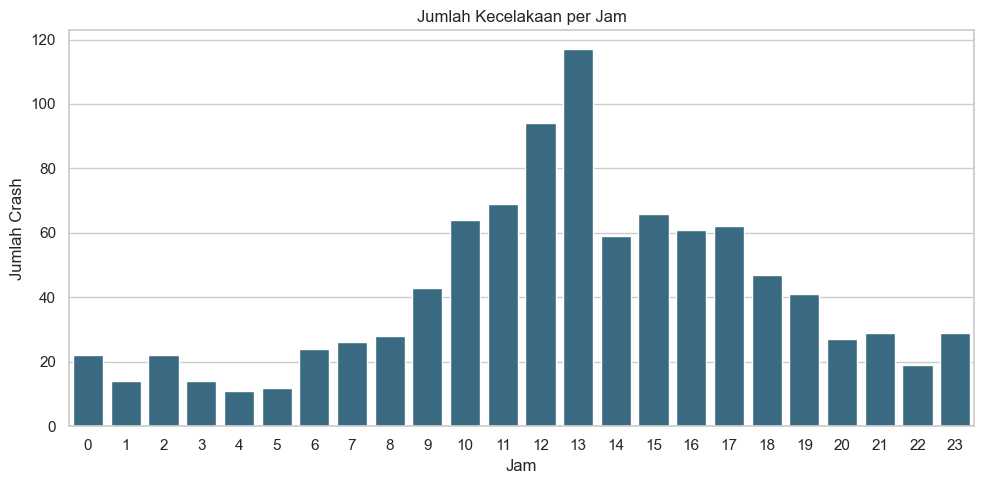

In [20]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=combined, x='crash_hour', color='#2f6f8f')
ax.set_title('Jumlah Kecelakaan per Jam')
ax.set_xlabel('Jam')
ax.set_ylabel('Jumlah Crash')
plt.tight_layout()
plt.show()

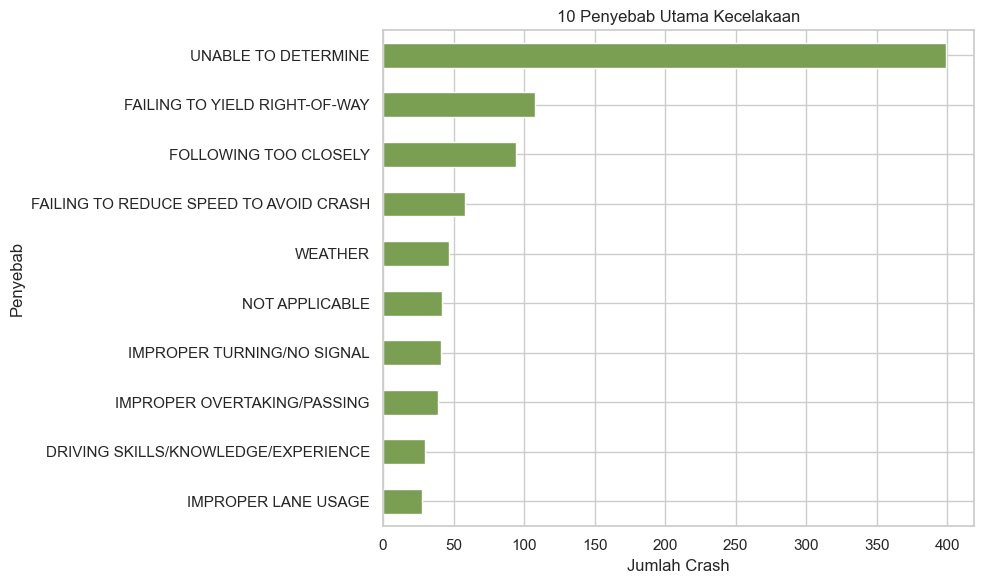

In [21]:
top_causes = combined['prim_contributory_cause'].value_counts().head(10).sort_values()
plt.figure(figsize=(10, 6))
top_causes.plot(kind='barh', color='#7a9e52')
plt.title('10 Penyebab Utama Kecelakaan')
plt.xlabel('Jumlah Crash')
plt.ylabel('Penyebab')
plt.tight_layout()
plt.show()

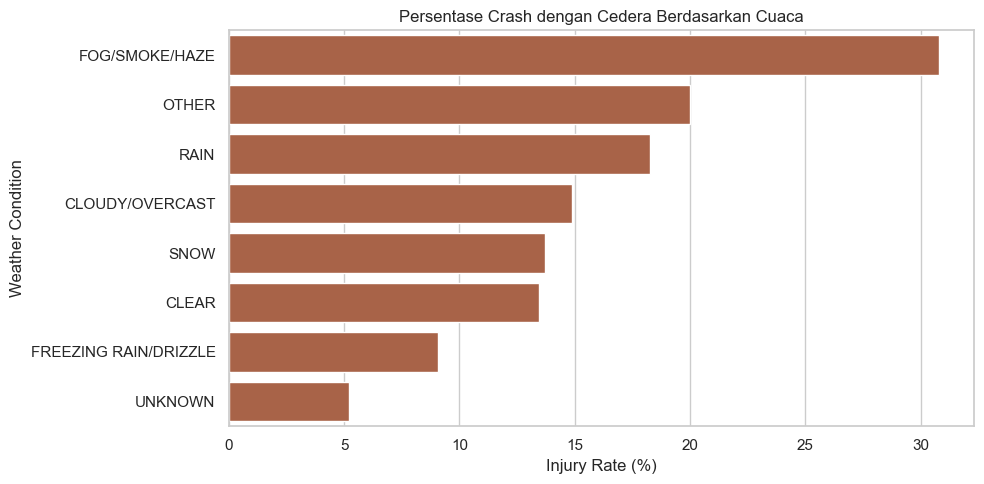

In [22]:
weather_injury = (
    combined.groupby('weather_condition')
    .agg(jumlah_crash=('crash_record_id', 'count'), injury_rate=('is_injury_crash', 'mean'))
    .query('jumlah_crash >= 5')
    .assign(injury_rate=lambda d: d['injury_rate'] * 100)
    .sort_values('injury_rate', ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=weather_injury.reset_index(), x='injury_rate', y='weather_condition', color='#b85c38')
plt.title('Persentase Crash dengan Cedera Berdasarkan Cuaca')
plt.xlabel('Injury Rate (%)')
plt.ylabel('Weather Condition')
plt.tight_layout()
plt.show()

## 8. Query SQLite untuk Analisis

In [23]:
with sqlite3.connect(DB_PATH) as conn:
    query_result = pd.read_sql_query("""
        SELECT
            weather_condition,
            COUNT(*) AS jumlah_crash,
            SUM(COALESCE(injuries_total, 0)) AS total_injuries,
            ROUND(AVG(CASE WHEN is_injury_crash = 1 THEN 1.0 ELSE 0.0 END) * 100, 2) AS injury_rate_percent
        FROM combined_crash_analysis
        GROUP BY weather_condition
        ORDER BY jumlah_crash DESC
        LIMIT 10
    """, conn)

query_result

,weather_condition,jumlah_crash,total_injuries,injury_rate_percent
0,CLEAR,572,109.0,13.46
1,SNOW,153,24.0,13.73
2,RAIN,93,23.0,18.28
3,UNKNOWN,77,4.0,5.19
4,CLOUDY/OVERCAST,74,12.0,14.86
5,FOG/SMOKE/HAZE,13,5.0,30.77
6,FREEZING RAIN/DRIZZLE,11,1.0,9.09
7,OTHER,5,1.0,20.00
8,SLEET/HAIL,2,2.0,100.00


## 9. Kesimpulan

In [24]:
print('Kesimpulan singkat:')
print(f"- Dataset gabungan memiliki {len(combined):,} baris, masing-masing mewakili satu crash.")
print(f"- Ada {combined['has_vehicle_record'].sum():,} crash yang memiliki data vehicle dan {combined['has_people_record'].sum():,} crash yang memiliki data people.")
print(f"- Total crash dengan cedera: {combined['is_injury_crash'].sum():,}.")
print(f"- Jam dengan jumlah crash terbanyak: {combined['crash_hour'].value_counts().idxmax()}.")
print(f"- Penyebab utama paling sering: {combined['prim_contributory_cause'].value_counts().idxmax()}.")
print(f"- Kondisi cuaca paling sering: {combined['weather_condition'].value_counts().idxmax()}.")

Kesimpulan singkat:
- Dataset gabungan memiliki 1,000 baris, masing-masing mewakili satu crash.
- Ada 490 crash yang memiliki data vehicle dan 459 crash yang memiliki data people.
- Total crash dengan cedera: 138.
- Jam dengan jumlah crash terbanyak: 13.
- Penyebab utama paling sering: UNABLE TO DETERMINE.
- Kondisi cuaca paling sering: CLEAR.
